# ampliscan demo

Walk through the core demultiplexer end-to-end:

1. Parse the PI's draft Excel sheet into an `ampliscan.Panel`.
2. Simulate paired-end FASTQ reads from the panel (synthetic ground-truth data).
3. Demultiplex and visualise per-bin read counts as a heatmap.
4. Edit anchors/barcodes interactively with widgets and re-run.
5. **Run on real `.fq.gz` files on disk** — the exact workflow you'll use on your PI's sequencer output.

Requires the `notebook` extras: `pip install -e ".[notebook]"`.

In [1]:
import sys, pathlib
# Make the package importable when running straight from a clone:
ROOT = pathlib.Path.cwd().parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

import ampliscan
from ampliscan import (
    Panel, MatchPolicy,
    simulate_reads, demux_records, write_bins,
    panel_from_excel,
)
print('ampliscan version:', ampliscan.__version__)

ampliscan version: 0.1.0


## 1. Parse the Excel panel

`panel_from_excel` scans the amplicon strings for the `(X100)` placeholder, infers the constant anchors (the 4 nt flanking the barcode on each side), and pulls each barcode together with the sample label (`F01`, `R03`, ...) embedded in the read ID.

In [2]:
EXCEL = r'C:/Users/ayush/Downloads/Data_Ayushman.xlsx'
panel = panel_from_excel(EXCEL, barcode_length=4, name='ayushman_v1')
print(panel.describe())

Panel: ayushman_v1
  5' anchor (fwd): GCTT
  3' anchor (fwd): ACAG
  5' anchor (rev): CTGT
  3' anchor (rev): AAGC
  barcode length:  4
  forward barcodes (5): F01=GCGT, F02=GTAG, F03=ACGC, F04=CTCG, F05=GCTC
  reverse barcodes (4): R01=ACGC, R02=CTAC, R03=GCGT, R04=CGAG
  total bins: 20


The 5'/3' anchors + barcode together form the **octanucleotide** discriminator we need:

In [3]:
import pandas as pd
octa_table = pd.DataFrame({
    "sample": list(panel.forward_barcodes),
    "5' octamer (anchor+bc)": [panel.forward_5p_anchor.lower() + bc for bc in panel.forward_barcodes.values()],
})
octa_table

,sample,5' octamer (anchor+bc)
0,F01,gcttGCGT
1,F02,gcttGTAG
2,F03,gcttACGC
3,F04,gcttCTCG
4,F05,gcttGCTC


## 2. Simulate paired-end reads

`simulate_reads` builds reads with structure `adapter | anchor5 | F-bc | random target | R-bc | anchor3 | adapter`, then introduces per-base substitution errors at the requested rate. Read 2 is the reverse complement, mirroring real Illumina output. Every read's ground-truth bin is encoded in its ID, so we can score accuracy.

In [6]:
r1, r2 = simulate_reads(panel, reads_per_bin=200, target_length=100,
                        error_rate=0.005, paired_end=True, seed=1)
print(f'Generated {len(r1)} paired reads ({panel.barcode_length*2}-nt barcoded amplicons)')
print(f'R1 example: {r1[0].id}\n  {r1[0].seq[:80]}...')
print(f'R2 example: {r2[0].id}\n  {r2[0].seq[:80]}...')

Generated 4000 paired reads (8-nt barcoded amplicons)
R1 example: sim000713_F01_R04_113
  AATGATACGGCGACCACCGAGATCTACACTCTTTCCCTACACGTCGCTCTTCCGATCTGCTTGCGTAAATGCTGCGGCCG...
R2 example: sim000713_F01_R04_113
  CAAGCAGAAGACGGCATACGAGATCGCTGATCGTGACTGGAGTTCAGACGTGTGCTCTTCCGATCTCTGTCTCGGATAAT...


## 3. Demultiplex and visualise

`MatchPolicy` controls strictness. Hamming distance is the default for short barcodes; enable `allow_indels=True` for Levenshtein if your library has indel-prone chemistry (e.g., long reads).

In [7]:
policy = MatchPolicy(anchor_mismatch=0, barcode_mismatch=1, allow_indels=False)
results = list(demux_records(iter(r1), panel, policy, mates=iter(r2)))

from collections import Counter
summary = Counter()
for res in results:
    summary[res.bin_name or f'unassigned:{res.reason}'] += 1

n = len(results)
assigned = sum(c for k, c in summary.items() if not k.startswith('unassigned'))
print(f'Total reads: {n}; Assigned: {assigned} ({assigned/n:.1%})')
for k, v in sorted(summary.items()):
    print(f'  {k:25s} {v}')

Total reads: 4000; Assigned: 3954 (98.9%)
  F01_R01                   198
  F01_R02                   200
  F01_R03                   199
  F01_R04                   199
  F02_R01                   200
  F02_R02                   197
  F02_R03                   196
  F02_R04                   198
  F03_R01                   199
  F03_R02                   197
  F03_R03                   195
  F03_R04                   199
  F04_R01                   197
  F04_R02                   195
  F04_R03                   197
  F04_R04                   195
  F05_R01                   197
  F05_R02                   197
  F05_R03                   199
  F05_R04                   200
  unassigned:barcode_ambiguous 1
  unassigned:barcode_unmatched 3
  unassigned:no_anchor      5
  unassigned:paired_end_disagreement 37


### Heatmap of reads per F x R bin

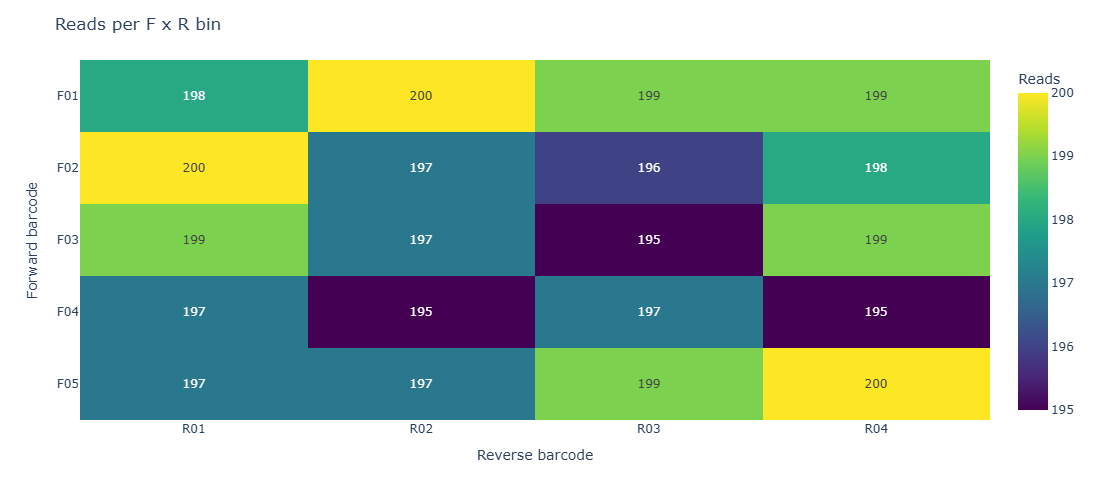

In [8]:
import plotly.express as px

f_names = list(panel.forward_barcodes)
r_names = list(panel.reverse_barcodes)
matrix = pd.DataFrame(0, index=f_names, columns=r_names)
for res in results:
    if res.bin_name:
        f, r = res.bin_name.split('_')
        matrix.loc[f, r] += 1

fig = px.imshow(matrix, text_auto=True, aspect='auto',
                color_continuous_scale='Viridis',
                labels=dict(x='Reverse barcode', y='Forward barcode', color='Reads'))
fig.update_layout(title='Reads per F x R bin', width=600, height=500)
fig.show()

### Write per-bin FASTQ files

`write_bins` drops one file per bin into the output directory. Unassigned reads land in `_unassigned.fq` for inspection.

In [9]:
out_dir = pathlib.Path('demux_out')
counts = write_bins(results, out_dir, output_format='fastq', compress=False)
print(f'Wrote {len(counts)} files to {out_dir.resolve()}')
for k, v in sorted(counts.items()):
    print(f'  {k:20s} {v:5d} reads')

Wrote 21 files to C:\Users\ayush\ampliscan\examples\demux_out
  F01_R01                198 reads
  F01_R02                200 reads
  F01_R03                199 reads
  F01_R04                199 reads
  F02_R01                200 reads
  F02_R02                197 reads
  F02_R03                196 reads
  F02_R04                198 reads
  F03_R01                199 reads
  F03_R02                197 reads
  F03_R03                195 reads
  F03_R04                199 reads
  F04_R01                197 reads
  F04_R02                195 reads
  F04_R03                197 reads
  F04_R04                195 reads
  F05_R01                197 reads
  F05_R02                197 reads
  F05_R03                199 reads
  F05_R04                200 reads
  _unassigned             46 reads


## 4. Interactive: edit anchors / barcodes live

Paste your own anchors and barcode sequences into the widgets below to rebuild the panel and re-run on the synthetic data. Use this when designing a new amplicon panel before committing to wet-lab work.

In [10]:
import ipywidgets as W
from IPython.display import display, clear_output

anchor5_w = W.Text(value=panel.forward_5p_anchor, description="5' anchor:")
anchor3_w = W.Text(value=panel.forward_3p_anchor, description="3' anchor:")
bc_len_w = W.IntSlider(value=panel.barcode_length, min=3, max=12, description='BC length:')
f_bc_w = W.Textarea(
    value='\n'.join(f'{k}\t{v}' for k, v in panel.forward_barcodes.items()),
    description='F barcodes', layout=W.Layout(height='150px', width='400px'))
r_bc_w = W.Textarea(
    value='\n'.join(f'{k}\t{v}' for k, v in panel.reverse_barcodes.items()),
    description='R barcodes', layout=W.Layout(height='150px', width='400px'))
bc_mm_w = W.IntSlider(value=1, min=0, max=3, description='BC mismatch:')
anchor_mm_w = W.IntSlider(value=0, min=0, max=2, description='Anchor mm:')
reads_per_bin_w = W.IntSlider(value=200, min=10, max=2000, step=10, description='Reads/bin:')
err_w = W.FloatLogSlider(value=0.005, base=10, min=-4, max=-1, step=0.1, description='Err rate:')
run_btn = W.Button(description='Run', button_style='primary')
out = W.Output()

def parse_bc(text):
    bcs = {}
    for line in text.strip().splitlines():
        parts = line.replace(',', '\t').split('\t')
        if len(parts) >= 2 and parts[0].strip() and parts[1].strip():
            bcs[parts[0].strip()] = parts[1].strip().upper()
    return bcs

def on_run(_):
    with out:
        clear_output()
        try:
            p2 = Panel(
                name='interactive',
                forward_5p_anchor=anchor5_w.value,
                forward_3p_anchor=anchor3_w.value,
                forward_barcodes=parse_bc(f_bc_w.value),
                reverse_barcodes=parse_bc(r_bc_w.value),
                barcode_length=bc_len_w.value,
            )
        except Exception as e:
            print('Panel build failed:', e); return
        print(p2.describe()); print()
        r1b, r2b = simulate_reads(p2, reads_per_bin=reads_per_bin_w.value,
                                  target_length=100, error_rate=err_w.value, seed=42)
        res = list(demux_records(iter(r1b), p2,
                                 MatchPolicy(anchor_mismatch=anchor_mm_w.value,
                                             barcode_mismatch=bc_mm_w.value),
                                 mates=iter(r2b)))
        n = len(res); assigned = sum(1 for x in res if x.bin_name)
        print(f'Assigned: {assigned}/{n} ({assigned/n:.1%})')
        mat = pd.DataFrame(0, index=list(p2.forward_barcodes), columns=list(p2.reverse_barcodes))
        for x in res:
            if x.bin_name:
                f, r = x.bin_name.split('_'); mat.loc[f, r] += 1
        fig = px.imshow(mat, text_auto=True, aspect='auto',
                        color_continuous_scale='Viridis',
                        labels=dict(x='R', y='F', color='Reads'))
        fig.update_layout(width=550, height=450, margin=dict(l=20, r=20, t=30, b=20))
        fig.show()

run_btn.on_click(on_run)

display(W.VBox([
    W.HBox([anchor5_w, anchor3_w, bc_len_w]),
    W.HBox([f_bc_w, r_bc_w]),
    W.HBox([bc_mm_w, anchor_mm_w, reads_per_bin_w, err_w]),
    run_btn, out
]))

## 5. Run on real `.fq.gz` files on disk

Everything above kept the reads in memory. The real workflow streams reads from
gzipped FASTQ files (what a sequencer actually produces) and writes per-bin
gzipped FASTQ output. The only thing you change for real PI data is the two
input paths.

We'll use the sample files at `examples/sample_data/sample_R{1,2}.fq.gz`
(generated previously with `simulate_reads` + `write_fastq`). If they don't
exist, the next cell creates them.

In [16]:
from ampliscan.io import write_fastq

DATA_DIR = pathlib.Path('sample_data')
R1_PATH = DATA_DIR / 'sg2_SRHT_Pool_S18_R1_001.fastq.gz'
R2_PATH = DATA_DIR / 'sg2_SRHT_Pool_S18_R2_001.fastq.gz'

if not R1_PATH.exists() or not R2_PATH.exists():
    DATA_DIR.mkdir(exist_ok=True)
    sim_r1, sim_r2 = simulate_reads(panel, reads_per_bin=500, target_length=100,
                                    error_rate=0.005, paired_end=True, seed=2026)
    write_fastq(sim_r1, R1_PATH)
    write_fastq(sim_r2, R2_PATH)
    print(f'Created {len(sim_r1)} paired reads on disk.')
else:
    print('Sample FASTQ files already present.')

for p in (R1_PATH, R2_PATH):
    print(f'  {p}  ({p.stat().st_size/1024:.1f} KB)')

Sample FASTQ files already present.
  sample_data\sg2_SRHT_Pool_S18_R1_001.fastq.gz  (214514.5 KB)
  sample_data\sg2_SRHT_Pool_S18_R2_001.fastq.gz  (232414.0 KB)


### Peek at the raw FASTQ

A quick sanity check that the file on disk is real, valid, gzipped FASTQ.

In [17]:
import gzip
with gzip.open(R1_PATH, 'rt') as fh:
    for i, line in enumerate(fh):
        if i >= 8:
            break
        print(line.rstrip())

@LL00129:47:2522FYLT4:1:1101:2068:1028 1:N:0:GTACATACTC+TATAGGTTGC
TNGTGACCTCCAATGAATAACCCGTTTGTGTTAATGGAACCCTCAGCTCAGAGCTACATGGTGAACCTTGGCAAAAGCACACCCCACATGGACTGCGAGACAGAGATCGGAAGAGCACACGTCTGAACTCCAGTCACGTACATACTCATCT
+
I#IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII
@LL00129:47:2522FYLT4:1:1101:12633:1028 1:N:0:GTACATACTC+TATAGGTTGC
GNTTGCGTACCTCCAATGAATAACCCGTTTGTGTTAATGGAACCCTCAGCTCAGAGCTCAGAACCTTGGCAAAAGCACACCCCACATGGACTCTACACAGAGATCGGAAGAGCACACGTCTGAACTCCAGTCACGTACATACTCATCTAGT
+
I#IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII*I*


### Stream the files through the demuxer

`iter_records` auto-detects the format from the extension (FASTQ vs FASTA, plain
vs `.gz`) and yields one `Record` at a time, so memory use stays flat even on
multi-GB sequencer files. To swap in our real data, change only
`R1_PATH` and `R2_PATH` above.

In [18]:
import time
from ampliscan import iter_records

policy_disk = MatchPolicy(anchor_mismatch=0, barcode_mismatch=1)

t0 = time.time()
disk_results = list(demux_records(
    iter_records(R1_PATH), panel, policy_disk, mates=iter_records(R2_PATH)
))
elapsed = time.time() - t0

n = len(disk_results)
assigned = sum(1 for r in disk_results if r.bin_name)
print(f'Demuxed {n} read pairs from gzipped FASTQ in {elapsed:.2f}s '
      f'({n/elapsed:,.0f} pairs/sec)')
print(f'Assigned: {assigned}/{n}  ({assigned/n:.1%})')

Demuxed 6592457 read pairs from gzipped FASTQ in 104.69s (62,974 pairs/sec)
Assigned: 5657118/6592457  (85.8%)


### Heatmap + reasons for unassigned reads

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

mat_disk = pd.DataFrame(0, index=list(panel.forward_barcodes),
                        columns=list(panel.reverse_barcodes))
reason_counts = Counter()
for r in disk_results:
    if r.bin_name:
        f, rv = r.bin_name.split('_')
        mat_disk.loc[f, rv] += 1
    else:
        reason_counts[r.reason or 'unknown'] += 1

fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.55, 0.45],
    horizontal_spacing=0.22,
    specs=[[{"type": "heatmap"}, {"type": "pie"}]],
    subplot_titles=("Reads per F x R bin", "Unassigned reasons"),
)

fig.add_trace(go.Heatmap(
    z=mat_disk.values, x=mat_disk.columns, y=mat_disk.index,
    text=mat_disk.values, texttemplate="%{text}", textfont=dict(color='white'),
    colorscale='Viridis',
    colorbar=dict(title='Reads', x=0.48, len=0.85, thickness=12, xpad=0),
), row=1, col=1)

if reason_counts:
    fig.add_trace(go.Pie(
        labels=list(reason_counts), values=list(reason_counts.values()),
        hole=0.35, sort=False,
        domain=dict(x=[0.66, 0.92]),
    ), row=1, col=2)

fig.update_xaxes(title_text='Reverse barcode', row=1, col=1)
fig.update_yaxes(title_text='Forward barcode', row=1, col=1, autorange='reversed')
fig.update_layout(
    width=1100, height=480,
    margin=dict(l=70, r=30, t=70, b=50),
    title_text=f'Demux of {R1_PATH.name} / {R2_PATH.name}',
    legend=dict(x=1.0, y=0.5, xanchor='left'),
)
fig.show()

### Write the demultiplexed reads to per-bin gzipped FASTQ

One file per `F_R` combination, plus `_unassigned.fq.gz` for inspection.
Open the output folder afterwards to download/share with your collaborators.

In [20]:
disk_out = pathlib.Path('demux_output')
disk_counts = write_bins(disk_results, disk_out, output_format='fastq', compress=True)
print(f'Wrote {len(disk_counts)} files to {disk_out.resolve()}\n')
pd.DataFrame(sorted(disk_counts.items()),
             columns=['bin', 'read_count']).style.bar(subset=['read_count'], color='#5e9bf5')

Wrote 21 files to C:\Users\ayush\ampliscan\examples\demux_output



,bin,read_count
0,F01_R01,360670
1,F01_R02,298459
2,F01_R03,226608
3,F01_R04,327616
4,F02_R01,58043
5,F02_R02,282571
6,F02_R03,891396
7,F02_R04,273134
8,F03_R01,222051
9,F03_R02,226157


## What's next

- Plug in real FASTQ files: `iter_records('reads.fq.gz')` and pass to `demux_records`.
- Persist a panel to YAML with `panel.to_yaml('my_panel.yaml')` and reload with `Panel.from_yaml(...)`.
- Future versions will add a CLI, HTML report, multiprocessing, BAM input, and per-bin consensus FASTA.